/tmp/ipykernel_782/737793508.py:9: RuntimeWarning: divide by zero encountered in divide
  M = (1/2) * special.erfc((x - (hbar * k * t / m)) / (np.sqrt(2 * hbar * 1j * t / m))) * np.exp(1j * (k * x - hbar * (k**2) * t / (2 * m)))
/tmp/ipykernel_782/737793508.py:9: RuntimeWarning: invalid value encountered in divide
  M = (1/2) * special.erfc((x - (hbar * k * t / m)) / (np.sqrt(2 * hbar * 1j * t / m))) * np.exp(1j * (k * x - hbar * (k**2) * t / (2 * m)))


56.94426218384722
173027.14272971128


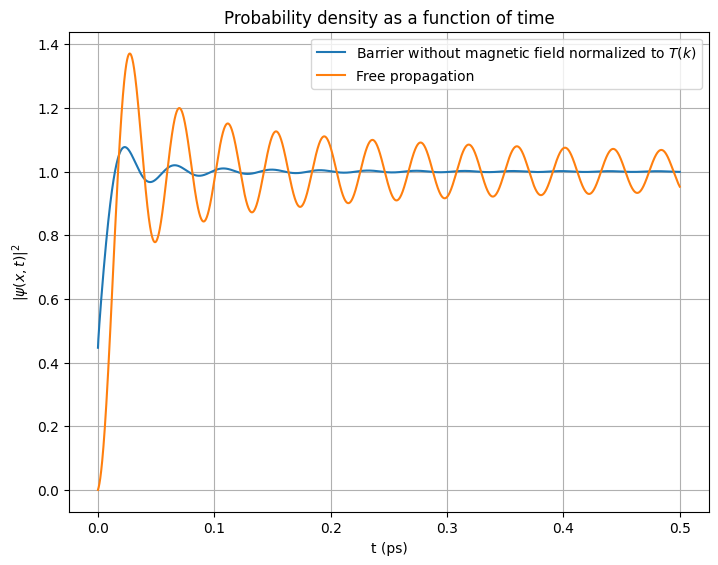

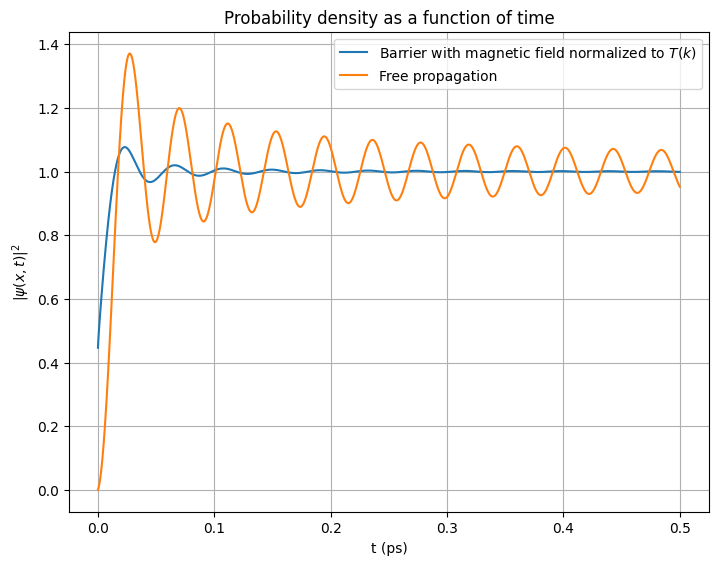

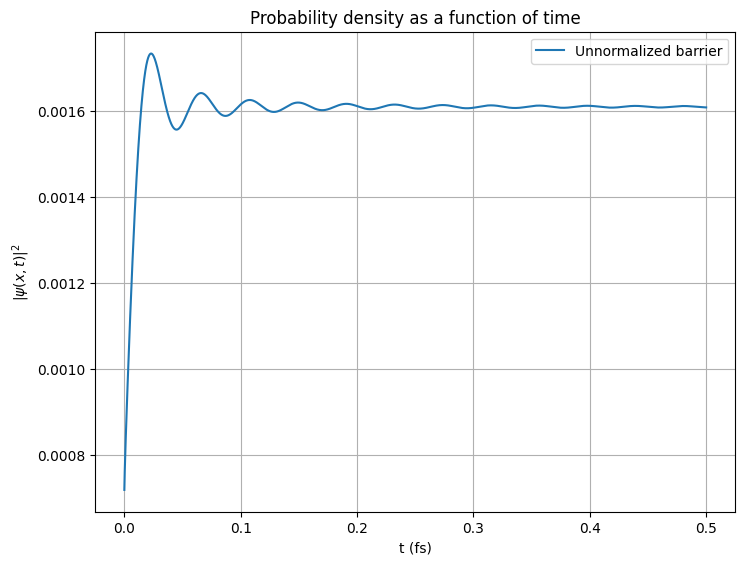

In [1]:
import sympy as sp
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import special
import math

def moshinsky_function(x, k, t, m, hbar):
    M = (1/2) * special.erfc((x - (hbar * k * t / m)) / (np.sqrt(2 * hbar * 1j * t / m))) * np.exp(1j * (k * x - hbar * (k**2) * t / (2 * m)))
    return M

# Probability density for the barrier at low energies without magnetic field for x > L
# Initial parameters
hbar = 6.582119e-4
V0 = 0.3
a = 50
c = 3e8
x = a
E0 = 0.1
m = 0.067 * 1e4 * 0.510998e6 / c**2
m_e = 0.067 * 5.6791e-8
K0 = np.sqrt((2 * m * E0) / (hbar**2))
Kv0 = np.sqrt((2 * m * V0) / (hbar**2))
Alpha = a * Kv0
Gamma = math.tanh(Alpha) * (Kv0 / 2)
Tk = (K0**2) / (math.cosh(Alpha)**2 * (K0**2 + Gamma**2))

# Initial values for the magnetic field contribution
omega = 9e-5
V_positive = V0 - hbar * omega / 2
V_negative = V0 + hbar * omega / 2
Kv0_positive = np.sqrt((2 * m * V_positive) / (hbar**2))
Kv0_negative = np.sqrt((2 * m * V_negative) / (hbar**2))
Alpha_positive = a * Kv0_positive
Alpha_negative = a * Kv0_negative
Gamma_positive = math.tanh(Alpha_positive) * Kv0_positive / 2
Gamma_negative = math.tanh(Alpha_negative) * Kv0_negative / 2

# Probability densities with magnetic field
t = np.linspace(0, 0.5, 10000)
Free = moshinsky_function(x, K0, t, m, hbar)
Free_conjugate = Free * np.conj(Free)
Psi_free = np.real(Free_conjugate)

Psi_up = ((1 / np.sqrt(2)) * ((K0 - 1j * Gamma_positive) / (math.cosh(Alpha_positive) * (K0**2 + Gamma_positive**2)))) * (K0 * moshinsky_function(x - a, K0, t, m, hbar) + 1j * Gamma_positive * moshinsky_function(x - a, -1j * Gamma_positive, t, m, hbar))
Psi_up_density = np.real(Psi_up * np.conj(Psi_up))

Psi_down = ((1 / np.sqrt(2)) * ((K0 - 1j * Gamma_negative) / (math.cosh(Alpha_negative) * (K0**2 + Gamma_negative**2)))) * (K0 * moshinsky_function(x - a, K0, t, m, hbar) + 1j * Gamma_negative * moshinsky_function(x - a, -1j * Gamma_negative, t, m, hbar))
Psi_down_density = np.real(Psi_down * np.conj(Psi_down))
Psi_total = Psi_down_density + Psi_up_density

# Probability density without magnetic field
FAC0 = (K0 - 1j * Gamma) / (math.cosh(Alpha) * (K0**2 + Gamma**2))
Psi = FAC0 * (K0 * moshinsky_function(x - a, K0, t, m, hbar) + 1j * Gamma * moshinsky_function(x - a, -1j * Gamma, t, m, hbar))
Psi_density = np.real(Psi * np.conj(Psi))

# Plot for the solution without magnetic field
fig = plt.figure(1)
ax = fig.add_axes([0, 0, 1, 1])
plt.grid()
line1, = plt.plot(t, Psi_density / Tk, label='Barrier without magnetic field normalized to $T(k)$')
line2, = plt.plot(t, Psi_free, label='Free propagation')
plt.legend(handles=[line1, line2], loc='upper right')
ax.set_title("Probability density as a function of time")
ax.set_xlabel("t (ps)")
ax.set_ylabel("$|\\psi(x,t)|^2$")
plt.savefig("figure.png")

# Plot for the solution with magnetic field
fig = plt.figure(2)
ax = fig.add_axes([0, 0, 1, 1])
plt.grid()
line1, = plt.plot(t, Psi_total / Tk, label='Barrier with magnetic field normalized to $T(k)$')
line2, = plt.plot(t, Psi_free, label='Free propagation')
plt.legend(handles=[line1, line2], loc='upper right')
ax.set_title("Probability density as a function of time")
ax.set_xlabel("t (ps)")
ax.set_ylabel("$|\\psi(x,t)|^2$")
plt.savefig("figure1000.png")

fig = plt.figure(3)
ax = fig.add_axes([0, 0, 1, 1])
plt.grid()
line1, = plt.plot(t, Psi_density, label='Unnormalized barrier')
plt.legend(handles=[line1], loc='upper right')
ax.set_title("Probability density as a function of time")
ax.set_xlabel("t (fs)")
ax.set_ylabel("$|\\psi(x,t)|^2$")
plt.savefig("figure1.png")

print(hbar**2 / (2 * m))
print(hbar / m)